### Prototype bayesian inference 

In [1]:
import os, sys, importlib

sys.path.append('./../') # rel. dir. to find toolbox 
from bayesbox import inference, plot as bplot
from npxtoolbox import plot, unpack

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gamma
from scipy.stats import norm

%matplotlib inline

#### Initialize for inference

In [16]:
# =============================================================================
# CONFIG 
# =============================================================================

# ----- 
METRIC = 'rate_calls_rec_s'
SCALE       = 1     
METRIC_TITLE  = 'calls/s' 
log = False
pdist = 'gaussian'

# Parameter grid for inference
param_lim_default = False

CREDIBILITY = 0.95           # HPD credible region probability content

TREATMENT_COL = 'treatment'
TREATMENTS    = ['saline', 'muscimol']

TREATMENT_PAL = {'saline': plt.cm.viridis(np.linspace(0.4,0.6,1)), 
                 'muscimol': plt.cm.magma(np.linspace(0.4,0.6,1))}
line_pal = {'saline': "#235E6E", 
            'muscimol': "#75276C"}


In [20]:
df = pd.read_csv('./../../data/vocal_data/combined_analysis_dataset.csv')

df['treatment'] = pd.Categorical(df['treatment'], categories=['saline', 'muscimol'], ordered=True)

## for playback
play_dat = df.loc[df['condition']!='spontaneous']

## trial
n_play_trials = (
play_dat
.groupby(['anim','sess_n','treatment','condition','rec_iter','trial_n'],observed=True)
.agg(n_calls_trial=('anim', 'size'),
     n_calls_orig_trial=('n_calls', lambda x: list(x.unique())[0]))
.reset_index() 
)
# for each trial, get trial's trig start time in original rec, trial response length, and stim dur
n_play_trials, _ =  unpack.pull_data_from_recondat(n_play_trials)

## recording
n_play_rec = (
n_play_trials
.groupby(['anim','sess_n','treatment','condition'],observed=True)
.agg(n_calls_rec=('n_calls_trial', 'sum'),
     n_calls_orig_rec=('n_calls_orig_trial', 'sum'),
     sum_trial_lens_rec=('seg_len_seconds','sum'))
.assign(rate_calls_rec_s=lambda df: df['n_calls_rec'] / df['sum_trial_lens_rec'])
.reset_index()
)
n_play_sess = (
n_play_trials
.groupby(['anim','sess_n','treatment'],observed=True)
.agg(n_calls_sess=('n_calls_trial', 'sum'),
     n_calls_orig_sess=('n_calls_orig_trial', 'sum'),
     sum_trial_lens_sess=('seg_len_seconds','sum'))
.assign(rate_calls_sess_s=lambda df: df['n_calls_sess'] / df['sum_trial_lens_sess'])
.assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 2,3,4, 2,1,4,3])
.reset_index()
)


## spontaneous
spont_dat = df.loc[df['condition']=='spontaneous']

## recording 
# number and rate of calls per 15 min chunks
n_spont_rec = (
spont_dat   
.groupby(['anim','sess_n','treatment','rec_n','rec_iter'],observed=True) 
.agg(n_calls_rec=('anim', 'size'), 
    n_calls_orig_rec=('n_calls', lambda x: list(x.unique())[0]), 
    rec_dur=('rec_dur', lambda x: list(x.unique())[0]))
.assign(rate_calls_rec_s=lambda df: df['n_calls_rec'] / df['rec_dur'])
.reset_index()
)
n_spont_sess = (   
n_spont_rec
.groupby(['anim','sess_n','treatment'],observed=True)
.agg(n_calls_sess=('n_calls_rec', 'sum'),
     n_calls_orig_sess=('n_calls_orig_rec', 'sum'),
     rec_dur_cum=('rec_dur','sum'))
.assign(rate_calls_sess_s=lambda df: df['n_calls_sess'] / df['rec_dur_cum'])
.assign(sess_n_sort=[1,2,3,4, 2,1,4,3, 1,2,3,4, 2,1,4,3])
.reset_index()
)
n_spont_rec, n_play_rec
n_spont_sess, n_play_sess

n_spontplay_sess = n_spont_sess.loc[~((n_spont_sess['anim']=='M1') & (n_spont_sess['sess_n']==1))].copy().reset_index(drop=True) 

n_spontplay_sess['ratio_rate_calls_pl_over_sp'] = (n_play_sess['rate_calls_sess_s']-n_spontplay_sess['rate_calls_sess_s'])/np.sum(n_play_sess['rate_calls_sess_s']-n_spontplay_sess['rate_calls_sess_s'])
n_spontplay_sess


,anim,sess_n,treatment,n_calls_sess,n_calls_orig_sess,rec_dur_cum,rate_calls_sess_s,sess_n_sort,ratio_rate_calls_pl_over_sp
0,F1,1,saline,7255,9228,4500.000000,1.612222,1,-0.053998
1,F1,2,muscimol,2977,4057,5003.194667,0.595020,2,0.161257
2,F1,3,saline,356,519,4552.008000,0.078207,3,0.043089
3,F1,4,muscimol,5584,6997,4500.000000,1.240889,4,0.266390
4,F2,1,muscimol,765,1147,4500.000000,0.170000,2,0.037577
5,F2,2,saline,678,1010,4500.000000,0.150667,1,0.039713
6,F2,3,muscimol,1994,2512,4500.000000,0.443111,4,0.033481
7,F2,4,saline,2900,12320,4500.000000,0.644444,3,0.036920
8,M1,2,muscimol,295,413,4500.000000,0.065556,2,0.032424
9,M1,3,saline,189,267,4500.000000,0.042000,3,0.042705


In [ ]:
# check
print(log, SCALE)

import seaborn as sns

fig, axes = plot.hist_hue(n_play_rec, x=METRIC, 
                        hue_palette=TREATMENT_PAL,
                        xlabel=METRIC_TITLE, 
                        scale=SCALE, 
                        log=log, binsize=0.6,   
                        alpha=0.5,                    
                        # split_by='anim', 
                        legend_bbox=(1.2,0.9),
                        title='playback',
                        density=True, sharey=True, 
                        )
fig, axes = plot.hist_hue(n_spont_rec, x=METRIC, 
                        hue_palette=TREATMENT_PAL,
                        xlabel=METRIC_TITLE, 
                        scale=SCALE, 
                        log=log, binsize=0.6,   
                        alpha=0.5,                    
                        # split_by='anim', 
                        legend_bbox=(1.2,0.9),
                        title='spontaneous',
                        density=True, sharey=True, 
                        )
fig, axes = plot.hist_hue(n_spontplay_sess, x='ratio_rate_calls_pl_over_sp', 
                        hue_palette=TREATMENT_PAL,
                        xlabel='ratio calls/s [playback over spontaneous]', 
                        scale=SCALE, 
                        log=log, binsize=0.02,   
                        alpha=0.5,                    
                        # split_by='anim', 
                        legend_bbox=(1.2,0.9),
                        # title=METRIC_TITLE,
                        density=True, sharey=True, 
                        )

#### Inference

In [6]:
MU_VALUES = np.arange(0.001, 4.01, 0.01)   # mean parameter
SIGMA_VALUES = np.arange(0.01, 5.01, 0.01)   # standard deviation parameter

In [44]:
importlib.reload(inference)

results = {}   

# CONTEXT = 'playback'
# df = n_play_rec

# CONTEXT = 'spontaneous'
# df = n_spont_rec

CONTEXT = 'ratio'
df = n_spontplay_sess
METRIC = 'ratio_rate_calls_pl_over_sp'
MU_VALUES = np.arange(0.0001, 4.01, 0.001)   # mean parameter
SIGMA_VALUES = np.arange(0.01, 5.01, 0.001) 

# for slice_name, slice_results in results.items():

for treatment in TREATMENTS:
    mask = df[TREATMENT_COL] == treatment

    data = df.loc[mask, METRIC].dropna().values * SCALE

    print(f'\n{treatment}  (n={len(data)})')
    
    res = inference.run_inference(data, MU_VALUES, SIGMA_VALUES, CREDIBILITY, dist=pdist)
    results[treatment] = res
    
    print(f'  P({CREDIBILITY}) for mu: [{res["bounds_a"][0]:.3f}, {res["bounds_a"][1]:.3f}]')
    print(f'  P({CREDIBILITY}) for sigma: [{res["bounds_b"][0]:.3f}, {res["bounds_b"][1]:.3f}]')


saline  (n=7)
  P(0.95) for mu: [0.000, 0.062]
  P(0.95) for sigma: [0.028, 0.103]

muscimol  (n=8)
  P(0.95) for mu: [0.026, 0.186]
  P(0.95) for sigma: [0.056, 0.188]


In [ ]:
# save
SAVEDIR = './../../results/voc_bayes'+'/'+METRIC+'/'+CONTEXT+'/'+pdist
# np.save(os.path.join(SAVEDIR, 'inference_results.npy'), results, allow_pickle=True)

#### 2d posterior plots

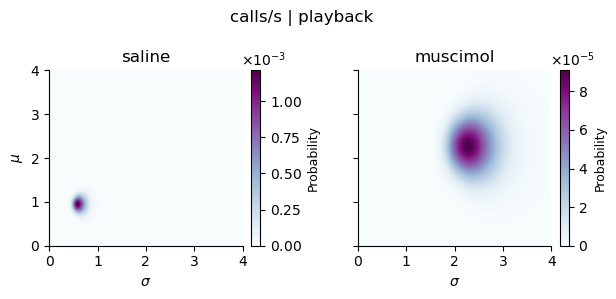

In [109]:
importlib.reload(bplot)
from matplotlib import ticker

param_lim_default = False

if param_lim_default:
    a_lim = None; b_lim = None
else:
    # a_lim, b_lim = bplot.auto_lims(results, nice=True) 
    a_lim = [0,4] 
    b_lim = [0,4]

label = f'{METRIC_TITLE} | {CONTEXT}'
fig, axes = bplot.posterior_2d_grid(
    results,
    a_values=list(results.values())[0]['a_values'],
    b_values=list(results.values())[0]['b_values'],
    treatment_order=TREATMENTS,
    cmap='BuPu',
    title=label,
    a_lim=a_lim, 
    b_lim=b_lim,
    # savedir=SAVEDIR,
    # filename=f'posterior_2d_{slice_name}.png',
)
fmt = ticker.ScalarFormatter(useMathText=True)
for ax in axes.flatten():
    cbar = ax.collections[0].colorbar
    fmt = ticker.ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((0, 0))   # always use scientific notation
    cbar.ax.yaxis.set_major_formatter(fmt)
    cbar.ax.yaxis.get_offset_text().set_x(4)
    # cbar.update_ticks()
for ext in ['png']:
    fig.savefig(os.path.join(SAVEDIR, f'posterior_2d_{CONTEXT}_PAPER.{ext}'),
            dpi=500, transparent=True, bbox_inches='tight')


#### 1d marginal plots

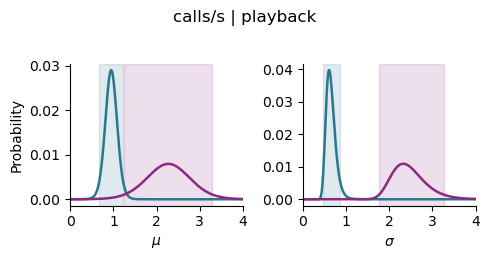

In [9]:

param_lim_default = False
if param_lim_default:
    a_lim = None; b_lim = None
else:
    a_lim, b_lim = bplot.auto_lims(results, nice=True) 
    # a_lim = [-0.1,0.3]
    a_lim = [0,4] 
    b_lim = [0,4]

label = f'{METRIC_TITLE} | {CONTEXT}'
fig, axes = bplot.marginal_posteriors(
    # A_VALUES, B_VALUES,
    list(results.values())[0]['a_values'],
    list(results.values())[0]['b_values'],
    results,
    treatment_palette=TREATMENT_PAL,
    credibility=CREDIBILITY,
    treatment_order=TREATMENTS,
    title=label, legend_bbox=(1.25, 1.0), legend=False, figsize=(5,2.5),
    a_lim=a_lim, b_lim=b_lim,
    # savedir=SAVEDIR,
    # filename=f'marginals_{CONTEXT}.png'
)
for ext in ['png','pdf']:
    fig.savefig(os.path.join(SAVEDIR, f'marginals_{CONTEXT}_PAPER.{ext}'),
            dpi=500, transparent=True, bbox_inches='tight')


#### Credible intervals

In [111]:
rows = []

CONTEXTS = ['playback', 'spontaneous']#, 'ratio']
METRICS = ['rate_calls_rec_s', 'rate_calls_rec_s']#, 'ratio_rate_calls_pl_over_sp']
for CONTEXT, METRIC in zip(CONTEXTS, METRICS):
    SAVEDIR = '/mnt/hpc/projects/BWFAFdeactivNpx/results/voc_bayes'+'/'+METRIC+'/'+CONTEXT+'/'+pdist
    results = np.load(os.path.join(SAVEDIR, 'inference_results.npy'), allow_pickle=True).item()
    for treatment, res in results.items():
        for param, bounds_key, mode_key in [('a', 'bounds_a', 'mode_a'), ('b', 'bounds_b', 'mode_b')]:
        # for param, bounds_key, mode_key in [('mu', 'bounds_a', 'mode_a'), ('sigma', 'bounds_b', 'mode_b')]:
            b = res[bounds_key]
            rows.append(dict(
                slice=CONTEXT,
                treatment=treatment,
                param=param,
                lower=b[0],
                upper=b[1],
                center=res[mode_key],
            ))

summary_df = pd.DataFrame(rows)
display(summary_df)

,slice,treatment,param,lower,upper,center
0,playback,saline,a,0.671,1.221,0.951
1,playback,saline,b,0.460,0.860,0.610
2,playback,muscimol,a,1.251,3.291,2.271
3,playback,muscimol,b,1.770,3.270,2.320
4,spontaneous,saline,a,0.321,0.831,0.581
5,spontaneous,saline,b,0.670,1.030,0.820
6,spontaneous,muscimol,a,0.131,0.591,0.361
7,spontaneous,muscimol,b,0.620,0.950,0.750


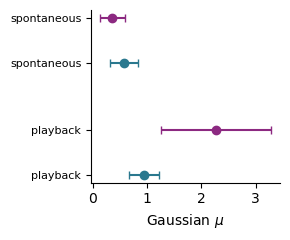

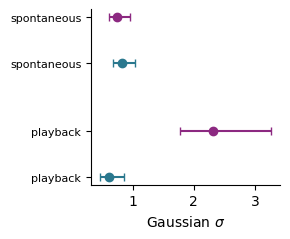

In [113]:
importlib.reload(bplot)
from matplotlib.ticker import FuncFormatter
from matplotlib import ticker

for param in ['a', 'b']:
# for param in ['mu', 'sigma']:
    fig, ax = bplot.credible_region_summary(
        summary_df[summary_df['param'] == param],
        param=param, #ylabel_map=slice_label_map,
        treatment_palette=TREATMENT_PAL, dist='gaussian',
        figsize=(3,2.5)
        # savedir=SAVEDIR,
        # filename=f'credible_summary_{param}.png',
    )
    # ax.invert_yaxis()

    # ax.set_xscale('log')
    # ax.xaxis.set_major_locator(ticker.FixedLocator([0, 0.001, 0.01, 0.1, 1, 2, 3, 4]))
    # ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x:g}'))
    # ax.set_xlabel(ax.get_xlabel() + ' (log scale)')

    fig.savefig(os.path.join(SAVEDIR, f'credible_summary_{param}_PAPER.pdf'), dpi=500, bbox_inches='tight', transparent=True) 
